In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ЗАДАНИЕ 1: Загрузка данных
df_project = pd.read_csv("sales_data_utf8.csv")
print(df_project.head())
print(df_project.shape)
print(df_project.info())

   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye           NaN

In [4]:
# ЗАДАНИЕ 2: Очистка и подготовка данных

# Проверяем пропуски
print(df_project.isnull().sum())

# Проверяем типы данных ДО очистки
print("\nТипы данных ДО очистки:")
print(df_project.dtypes)

# Удаляем ненужный столбец
df_project = df_project.drop(columns=["ADDRESSLINE2"])

# Заполняем категориальные пропуски значением "Unknown"
df_project["STATE"] = df_project["STATE"].fillna("Unknown")
df_project["TERRITORY"] = df_project["TERRITORY"].fillna("Unknown")

# POSTALCODE — это категория (почтовый код), не число, поэтому заполняем "Unknown"
df_project["POSTALCODE"] = df_project["POSTALCODE"].fillna("Unknown")

# Проверка дубликатов
print("Дубликаты:", df_project.duplicated().sum())

# Приводим ORDERDATE к формату datetime
df_project["ORDERDATE"] = pd.to_datetime(df_project["ORDERDATE"])

# Проверяем типы данных ПОСЛЕ всех преобразований
print("\nТипы данных ПОСЛЕ очистки:")
print(df_project.dtypes)

# Проверяем размер датасета после очистки
print("Размер датасета после очистки:", df_project.shape)

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

Типы данных ДО очистки:
ORDERNUMBER                  int64
QUANTITYORDERED              int64
PRICEEACH                  float64
ORDERLINENUMBER              int64
SALES                      float64
ORDERDATE           datetime64[ns]
STATUS                      object
QTR_ID                       int64
MONTH_ID                     int64
YEAR_ID                      int64
PRODUCTLINE                 object
MSRP                         int64
PRODUCTCODE   

KeyError: "['ADDRESSLINE2'] not found in axis"

In [5]:
# ЗАДАНИЕ 3: Базовый анализ продаж

# 1. Общее количество проданных товаров и общая выручка
total_quantity = df_project["QUANTITYORDERED"].sum()
total_revenue = df_project["SALES"].sum()
print(f"Всего продано товаров: {total_quantity}")
print(f"Общая выручка: {total_revenue:,.2f}")

Всего продано товаров: 99067
Общая выручка: 10,032,628.85


In [6]:
# 2. Продажи по годам и месяцам
sales_by_month = df_project.groupby(["YEAR_ID", "MONTH_ID"])["SALES"].sum().reset_index()
print(sales_by_month)

    YEAR_ID  MONTH_ID       SALES
0      2003         1   129753.60
1      2003         2   140836.19
2      2003         3   174504.90
3      2003         4   201609.55
4      2003         5   192673.11
5      2003         6   168082.56
6      2003         7   187731.88
7      2003         8   197809.30
8      2003         9   263973.36
9      2003        10   568290.97
10     2003        11  1029837.66
11     2003        12   261876.46
12     2004         1   316577.42
13     2004         2   311419.53
14     2004         3   205733.73
15     2004         4   206148.12
16     2004         5   273438.39
17     2004         6   286674.22
18     2004         7   327144.09
19     2004         8   461501.27
20     2004         9   320750.91
21     2004        10   552924.25
22     2004        11  1089048.01
23     2004        12   372802.66
24     2005         1   339543.42
25     2005         2   358186.18
26     2005         3   374262.76
27     2005         4   261633.29
28     2005   

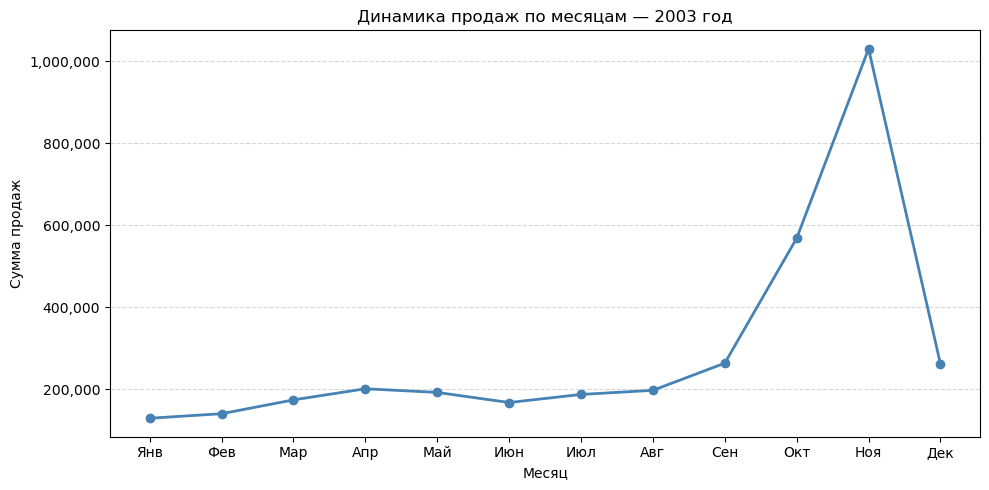

In [7]:
# 3. Линейный график продаж по месяцам за 2003 год
sales_2003 = sales_by_month[sales_by_month["YEAR_ID"] == 2003]

plt.figure(figsize=(10, 5))
plt.plot(sales_2003["MONTH_ID"], sales_2003["SALES"], marker="o", color="steelblue", linewidth=2)
plt.title("Динамика продаж по месяцам — 2003 год")
plt.xlabel("Месяц")
plt.ylabel("Сумма продаж")
plt.xticks(range(1, 13), ["Янв","Фев","Мар","Апр","Май","Июн",
                           "Июл","Авг","Сен","Окт","Ноя","Дек"])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\Shamziya\AppData\Local\Temp\ipykernel_3040\3944399441.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_products, x="Категория продукта", y="Выручка", palette="Blues_d")


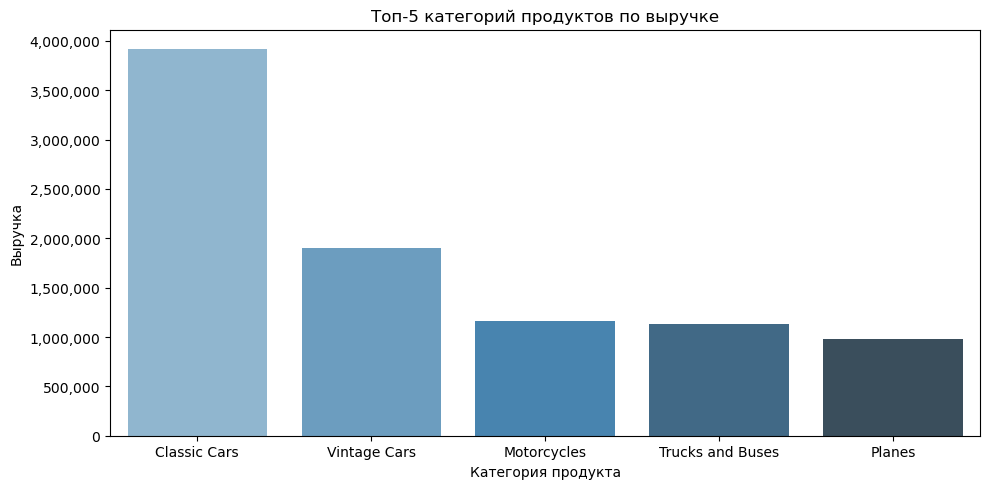

In [8]:
# 4. Топ-5 продуктов по выручке
top5_products = df_project.groupby("PRODUCTLINE")["SALES"].sum().nlargest(5).reset_index()
top5_products.columns = ["Категория продукта", "Выручка"]

plt.figure(figsize=(10, 5))
sns.barplot(data=top5_products, x="Категория продукта", y="Выручка", palette="Blues_d")
plt.title("Топ-5 категорий продуктов по выручке")
plt.xlabel("Категория продукта")
plt.ylabel("Выручка")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

                Клиент  Средний чек
46       Leslie Murphy  4674.827647
21  Frederique Citeaux  4233.604211
51      Marie Bertrand  4226.246957
66    Pascale Cartrain  4180.012500
29          Jeff Young  4119.519583
34          Julie King  4075.791600
17     Elizabeth Devon  4069.250690
39      Jytte Petersen  4028.933333
19      Eric Natividad  4023.015814
76           Sue Frick  4000.256750


C:\Users\Shamziya\AppData\Local\Temp\ipykernel_3040\2768747043.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_clients, x="Средний чек", y="Клиент", palette="Purples_d")


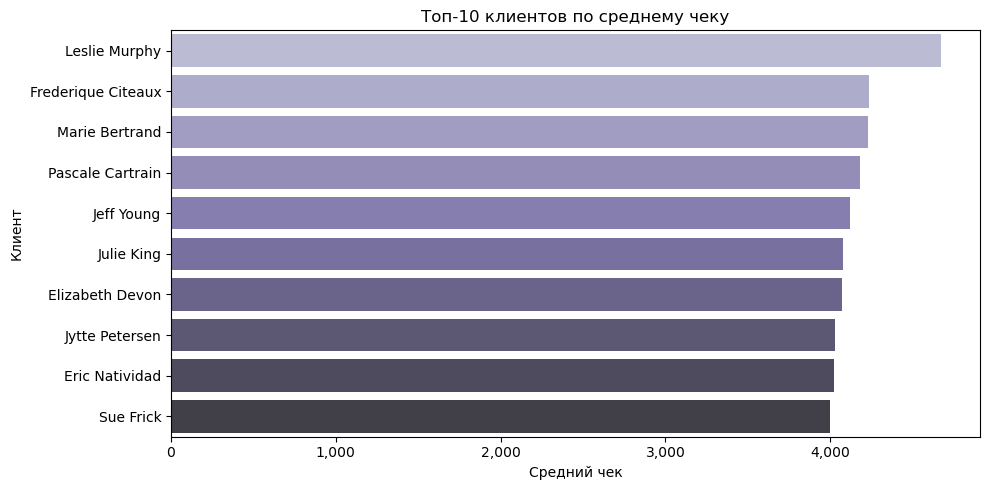

In [9]:
# ЗАДАНИЕ 4: Анализ по клиентам и регионам

# 1. Средний чек на клиента

# Создаём колонку с именем клиента
df_project["CLIENT_NAME"] = df_project["CONTACTFIRSTNAME"] + " " + df_project["CONTACTLASTNAME"]

# Создаём колонку среднего чека — среднее значение SALES по каждому клиенту
df_project["AVG_CHECK"] = df_project.groupby("CLIENT_NAME")["SALES"].transform("mean")

# Группируем по клиенту и считаем средний чек
avg_check_per_client = df_project.groupby("CLIENT_NAME")["SALES"].mean().reset_index()
avg_check_per_client.columns = ["Клиент", "Средний чек"]

# Топ-10 клиентов по среднему чеку
top10_clients = avg_check_per_client.nlargest(10, "Средний чек")
print(top10_clients)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_clients, x="Средний чек", y="Клиент", palette="Purples_d")
plt.title("Топ-10 клиентов по среднему чеку")
plt.xlabel("Средний чек")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

  Территория     Выручка     Доля %
0       APAC   746121.83   7.436952
1       EMEA  4979272.41  49.630785
2      Japan   455173.22   4.536929
3    Unknown  3852061.39  38.395334


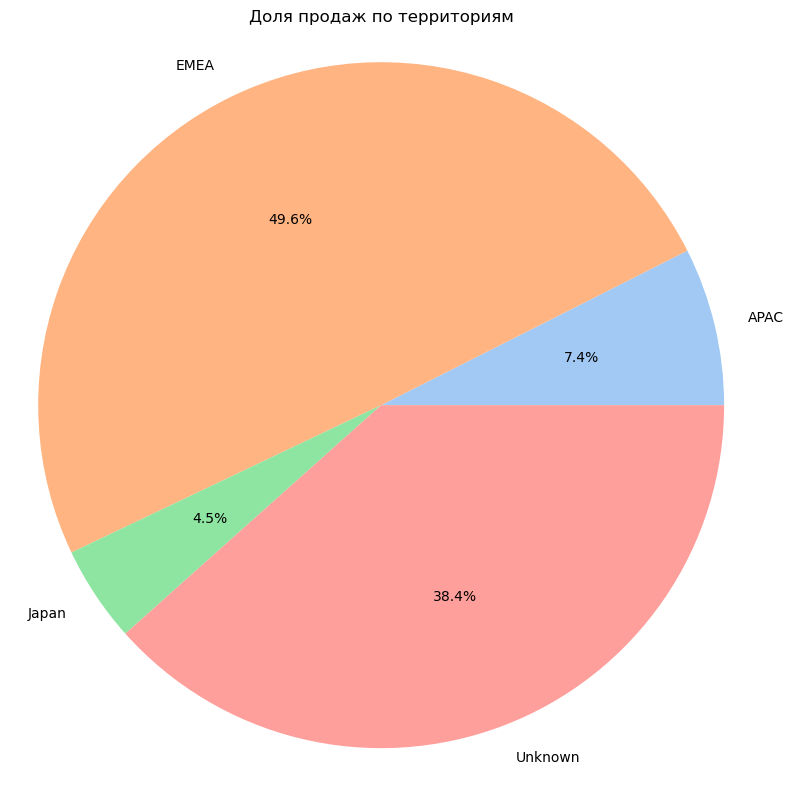

In [10]:
# 2. Доля продаж по территориям — Pie chart

# Считаем выручку по TERRITORY
sales_by_territory = df_project.groupby("TERRITORY")["SALES"].sum().reset_index()
sales_by_territory.columns = ["Территория", "Выручка"]

# Создаём колонку с процентной долей продаж каждой территории
sales_by_territory["Доля %"] = sales_by_territory["Выручка"] / total_revenue * 100

print(sales_by_territory)

# Строим Pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    sales_by_territory["Доля %"],
    labels=sales_by_territory["Территория"],
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel")
)
plt.title("Доля продаж по территориям")
plt.axis("equal")
plt.tight_layout()
plt.show()